# CUSTOMER CHURN PREDICTION USING MACHINE LEARNING
---
## Business Problem:
Customer churn is one of the biggest challenges for
subscription-based businesses.

The objective of this project is to predict whether a
customer is likely to leave the company and identify
the key factors driving churn.

## Business Benefits:
- Improve customer retention
- Reduce revenue loss
- Enable targeted retention campaigns
- Support business decision-making

Author: Subhankar Mondal

## Data Information

- customerID: A unique identifier for each customer.
- gender: The gender of the customer (Male/Female).
- SeniorCitizen: Indicates if the customer is a senior citizen (1 = Yes, 0 = No).
- Partner: Indicates if the customer has a partner (Yes/No).
- Dependents: Indicates if the customer has dependents (Yes/No).
- tenure: Number of months the customer has stayed with the company.
- PhoneService: Indicates if the customer has a phone service (Yes/No).
- MultipleLines: Indicates if the customer has multiple lines (Yes/No/No phone service).
- InternetService: Type of internet service (DSL, Fiber optic, None).
- OnlineSecurity: Indicates if the customer has online security add-ons (Yes/No/No internet service).
- DeviceProtection: Indicates if the customer has device protection add-ons (Yes/No/No internet service).
- TechSupport: Indicates if the customer has tech support add-ons (Yes/No/No internet service).
- StreamingTV: Indicates if the customer streams TV services (Yes/No/No internet service).
- StreamingMovies: Indicates if the customer streams movies (Yes/No/No internet service).
- Contract: Type of contract (Month-to-month, One year, Two year).
- PaperlessBilling: Indicates if the customer uses paperless billing (Yes/No).
- PaymentMethod: The payment method used (e.g., Electronic check, Mailed check, Bank transfer, Credit card).
- MonthlyCharges: Monthly charges for the customer.
- TotalCharges: Total charges billed to the customer.
- Churn: Indicates if the customer has churned (Yes/No).

In [11]:
# ==============================================================================
# STEP 1: ENVIRONMENT SETUP & DEPENDENCIES
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve
)

# Configuration settings for clean outputs and notebook visualization
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Environment configured successfully. Dependencies loaded.")

Environment configured successfully. Dependencies loaded.


In [12]:
# ==============================================================================
# STEP 2: DATA INGESTION & DATA INTEGRITY AUDITING
# ==============================================================================
# Load dataset asset
df = pd.read_csv(r'D:\Data Analytics Project\customer_churn.csv')

print("--- 1. Structural Dimensions ---")
print(f"Total Records: {df.shape[0]} | Total Features: {df.shape[1]}")

print("\n--- 2. Data Type & Schema Audit ---")
print(df.info())

print("\n--- 3. Missing Value Distribution ---")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No structural NaN values detected.")

print("\n--- 4. Duplicate Row Assessment ---")
duplicate_count = df.duplicated().sum()
print(f"Identical duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("--> Duplicate records successfully purged from the dataframe.")

--- 1. Structural Dimensions ---
Total Records: 7043 | Total Features: 21

--- 2. Data Type & Schema Audit ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 no

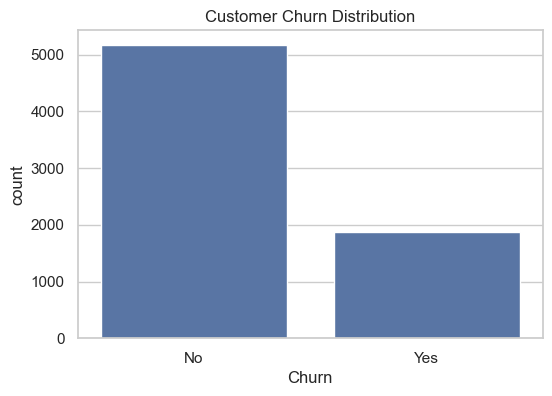

In [13]:
# Target Variable Analysis

plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

Evaluating continuous distributions for outliers: ['tenure', 'MonthlyCharges', 'TotalCharges']


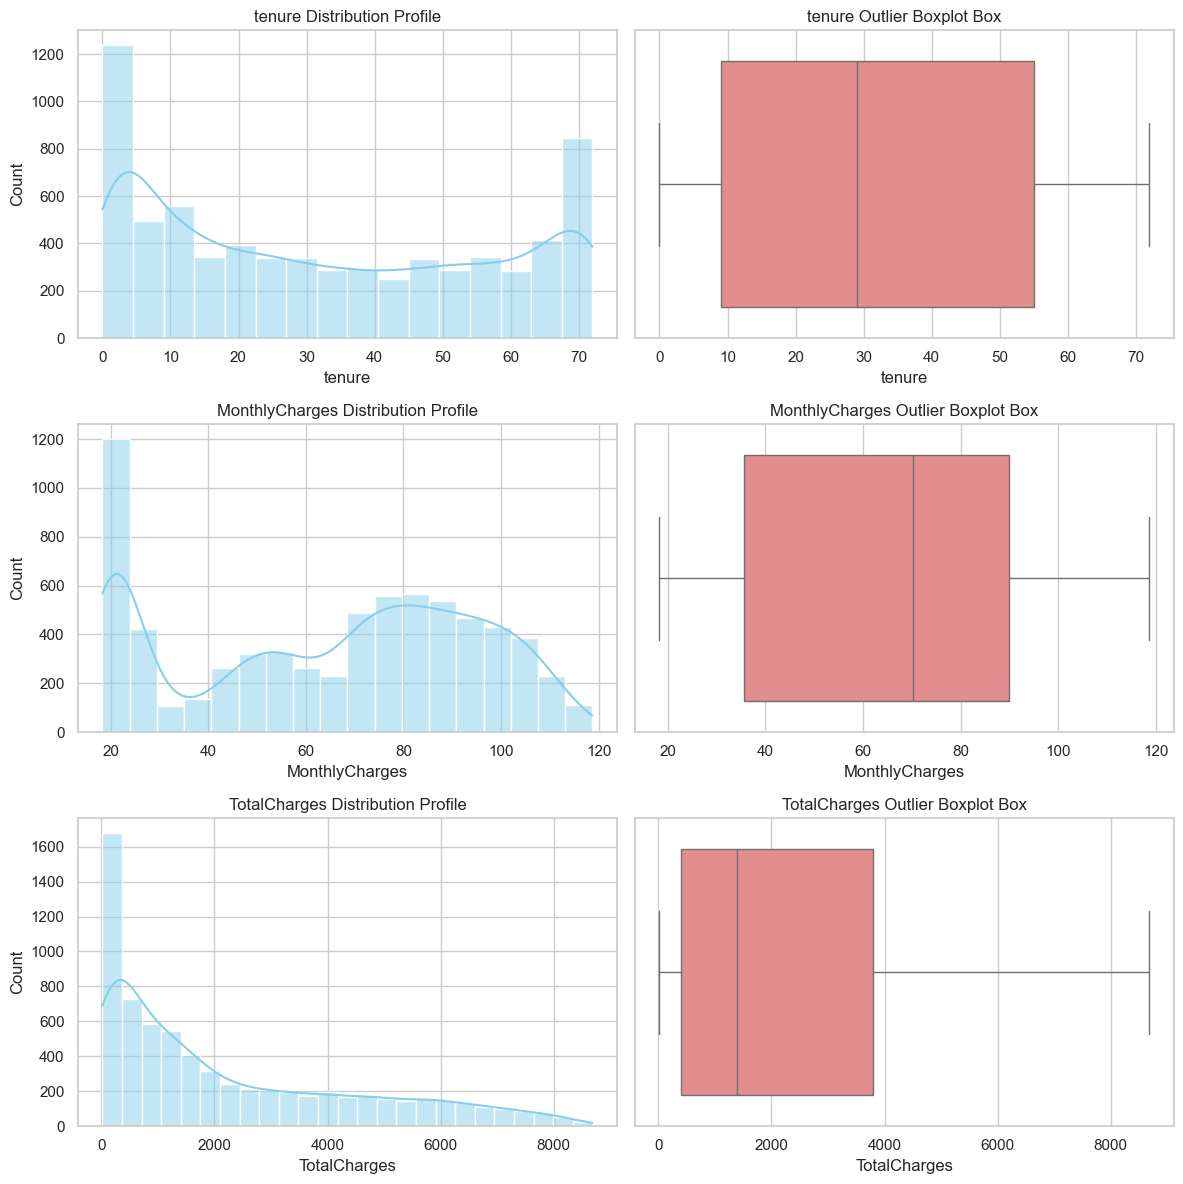

In [14]:
# ==============================================================================
# STEP 3: OUTLIER PROFILING VIA HISTOGRAMS & BOXPLOTS
# ==============================================================================
# Coerce TotalCharges to numeric early to include it in the outlier profiling
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    # Impute missing records with the column median to protect data integrity
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Identify continuous features for distribution analysis
continuous_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'SeniorCitizen' in continuous_features:
    continuous_features.remove('SeniorCitizen')

print(f"Evaluating continuous distributions for outliers: {continuous_features}")

# Generate dynamic data visualization distribution matrix
fig, axes = plt.subplots(len(continuous_features), 2, figsize=(12, 4 * len(continuous_features)))
if len(continuous_features) == 1:
    axes = np.array([axes])

for i, col in enumerate(continuous_features):
    # Left plot: Data density distribution
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} Distribution Profile')
    
    # Right plot: Outlier scan
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'{col} Outlier Boxplot Box')

plt.tight_layout()
plt.show()

In [15]:
# ==============================================================================
# STEP 4: CATEGORICAL ENCODING & ARRAY ISOLATION
# ==============================================================================
# Drop primary unique key records to remove architectural noise
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Encode Categorical Fields safely using explicit tracking dictionaries
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Map Target Class Variable to binary identifiers
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Segregate data space boundaries
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Data encoding, type stabilization, and matrix divisions finalized.")

Data encoding, type stabilization, and matrix divisions finalized.


In [16]:
# ==============================================================================
# STEP 5: TRAIN-TEST SPLIT (Preventing Data Leakage)
# ==============================================================================
# Split using stratification to ensure identical baseline churn rates in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=23, stratify=y
)

# Standardize numerical features using training statistics only
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Training Matrix Boundary Set: {X_train.shape}")
print(f"Testing Matrix Boundary Set: {X_test.shape}")

Training Matrix Boundary Set: (5634, 19)
Testing Matrix Boundary Set: (1409, 19)


In [17]:
# ==============================================================================
# STEP 6: MODEL ARCHITECTURE & HYPERPARAMETER TUNING
# ==============================================================================
# Define structural foundational estimator
rf_base = RandomForestClassifier(random_state=23)

# Establish search matrix parameters
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 7, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', None]
}

print("--- Initializing Grid Search Execution Engine ---")
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=3, 
    scoring='recall', # Focus evaluation metrics on optimizing recall matrix weights
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"\nOptimal Parameter Array Extracted: {grid_search.best_params_}")

--- Initializing Grid Search Execution Engine ---
Fitting 3 folds for each of 120 candidates, totalling 360 fits

Optimal Parameter Array Extracted: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}



             MODEL PERFORMANCE REPORT             
Accuracy Score  : 0.7367
Precision Score : 0.5026 (Ability to minimize False Positives)
Recall Score    : 0.7888 (Ability to capture true churners)
F1-Score Metric : 0.6139
ROC-AUC Index   : 0.8315

Detailed Classification Metrics Table:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



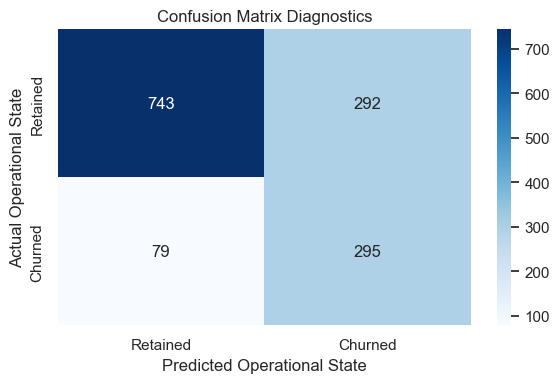

In [18]:
# ==============================================================================
# STEP 7: EVALUATION & PERFORMANCE METRICS
# ==============================================================================
# Execute inference calls across validation subsets
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate global performance KPIs
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n==================================================")
print("             MODEL PERFORMANCE REPORT             ")
print("==================================================")
print(f"Accuracy Score  : {accuracy:.4f}")
print(f"Precision Score : {precision:.4f} (Ability to minimize False Positives)")
print(f"Recall Score    : {recall:.4f} (Ability to capture true churners)")
print(f"F1-Score Metric : {f1:.4f}")
print(f"ROC-AUC Index   : {roc_auc:.4f}")
print("==================================================")

print("\nDetailed Classification Metrics Table:")
print(classification_report(y_test, y_pred))

# Render confusion matrix heatmap graphic
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix Diagnostics')
plt.xlabel('Predicted Operational State')
plt.ylabel('Actual Operational State')
plt.tight_layout()
plt.show()

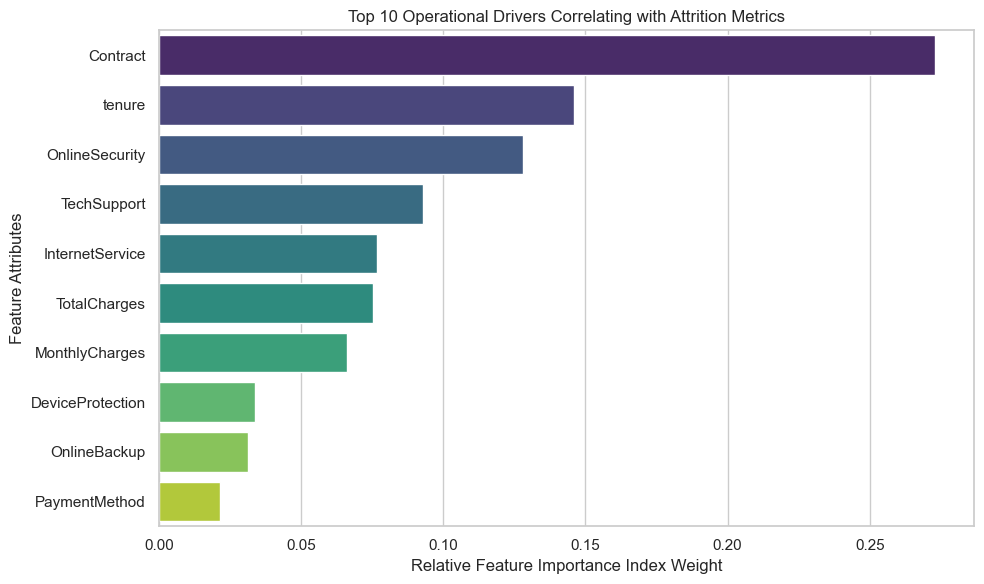


--- Top Root Drivers of Customer Churn ---
        Feature  Importance
       Contract    0.273034
         tenure    0.145985
 OnlineSecurity    0.128184
    TechSupport    0.092879
InternetService    0.076740


In [19]:
# ==============================================================================
# STEP 8: EXPLAINABLE AI — FEATURE IMPORTANCE EXTRACTION
# ==============================================================================

# Isolate internal node split frequencies to track feature importances
importances = best_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Visualize primary feature weights
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Operational Drivers Correlating with Attrition Metrics')
plt.xlabel('Relative Feature Importance Index Weight')
plt.ylabel('Feature Attributes')
plt.tight_layout()
plt.show()

print("\n--- Top Root Drivers of Customer Churn ---")
print(feature_imp_df.head(5).to_string(index=False))

# Business Conclusion

### BUSINESS INSIGHTS

1. Customers with shorter tenure show higher churn.

2. Monthly charges significantly influence churn.

3. Contract type impacts retention.

4. Electronic payment customers have
   higher churn probability.

### RECOMMENDATIONS

- Offer loyalty discounts.
- Promote annual contracts.
- Launch targeted retention campaigns.
- Focus on high-risk customer segments.